# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.



##1.Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

##2.Project Objectives



*   Explore and understand the dataset.

*  Clean and prepare the data for analysis.

*  Examine how agricultural performance varies across seasons.

*  Identify important seasonal patterns and trends.  
*  Investigate relationships between seasonal conditions and agricultural outcomes.


*   Compare relevant groups within different seasons.


*  Identify significant differences or unusual patterns.


*   Apply appropriate statistical and visualization techniques

*   Interpret findings based on evidence from the dataset.
*  Develop meaningful conclusions and data-driven recommendations.





##3.Dataset

The dataset represents agricultural activities carried out across different seasons,
geographical areas and farming conditions. It contains information related to farming
practices, environmental conditions, crop production, resource usage and economic
performance.

Dataset file : seasonal_agriculture_performance_dataset.csv

In [5]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 40)

In [7]:
#load dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Dataset loaded")

Dataset loaded


##4.Initial Data Understanding

In [ ]:
#Shape of dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
#Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
#last 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
#Random sample
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [ ]:
#column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
#data types and no null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
#numerical summary
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
#categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


##5.Data Quality Analysis

In [9]:
#missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean()*100).sort_values(ascending=False)
missing_summary = pd.DataFrame({"MissingCount":missing,
                                "Missing_percent":missing_percent.round(2)})
missing_summary[missing_summary["MissingCount"]>0]

,MissingCount,Missing_percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


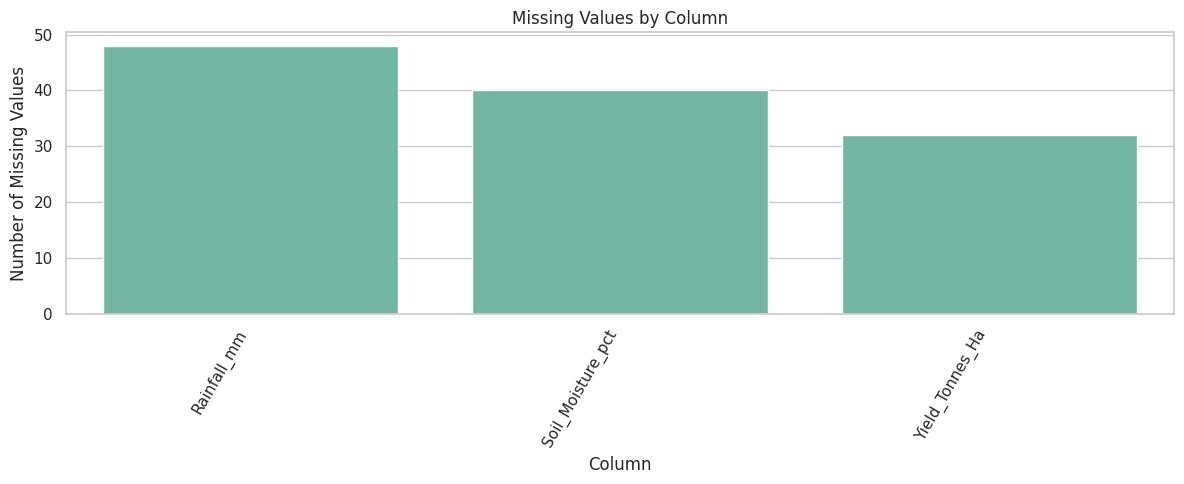

In [10]:
# Visualize missing values
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [11]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
#remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("shape after removing duplicates",df.shape)

shape after removing duplicates (4000, 28)


In [13]:
#check datatype
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [18]:
#check unique value for categorical column
categorical_column = df.select_dtypes(include="object").columns
for col in categorical_column:
  print(f"\n{col}:")
  print(df[col].nunique(),"unique value")
  print(df[col].dropna().unique()[:20])



Farm_ID:
4000 unique value
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique value
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique value
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique value
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique value
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique value
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [19]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


##Missing Value Treatment

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:


*   Remove records only when justified.
*   Fill numerical values using an appropriate statistic when appropriate.


*   Fill categorical values using a suitable category or method.
*   Clearly document why the chosen approach is reasonable.





In [20]:
# Example: median imputation for numerical columns
# Students should review missingness before deciding whether to use this approach.
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


##6. Feature / Variable Review
Review the available variables and classify them conceptually as:


*  Identifier variables

*   Categorical variables



*   Numerical variables

*   Environmental variables
*  Operational variables

*   Production/performance variables
*   Economic variables






task: Explain which variables are most relevant to the seasonal-performance problem.

In [22]:
# numerical and categorical columns

numeric_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("numerical column")
print(numeric_columns)
print("categorical column")
print(categorical_columns)

numerical column
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
categorical column
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


##7. Statistical Analysis

Perform descriptive statistical analysis to understand the distribution and variation of the data.



In [23]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [24]:
# Median and standard deviation
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


In [25]:
# Seasonal descriptive summary
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct                   \
                    mean median       std         mean median       std   
Season                                                                    
Kharif         28.454019   28.5  2.510166    71.812591  71.90  8.861902   
Rabi           23.489183   23.5  2.459561    57.893178  58.10  9.001575   
Zaid           31.042088   31.0  2.554911    52.012121  52.35  9.051898   

       Sunlight_Hours_Day                    Soil_pH                   \
                     mean median       std      mean median       std   
Season                                                                  
Kharif           6.793367    6.8  0.977077  6.727993  6.730  0.642986   
Rabi             7.589797    7.6  1.001779  6.673749  6.670  0.638481   
Zaid             8.178788    8.2  1.045260  6.694865  6.655  0.642794   

       Soil_Moisture_pct         ... Market_Price_INR_Tonne                \
                    mean median  ...                 median           std   
Season                           ...                                        
Kharif         31.149859   31.1  ...                25793.0  30301.557639   
Rabi           24.069392   24.0  ...                26041.0  30309.563409   
Zaid           19.279630   19.1  ...                25749.5  30086.234044   

       Total_Cost_INR                             Revenue_INR            \
                 mean    median            std           mean    median   
Season                                                                    
Kharif  531804.408094  524840.0  298487.687038  710719.055649  520196.0   
Rabi    513836.578365  506733.0  288386.891838  601526.048556  438156.0   
Zaid    543976.728956  534833.0  297576.858682  519171.904040  373700.5   

                          Profit_INR                         Water_Used_m3  \
                  std           mean   median            std          mean   
Season                                                                       
Kharif  708710.370061  178914.647555  38808.0  611549.783883   6102.201237   
Rabi    584545.521423   87689.470191  -3187.0  489901.254255   5846.987093   
Zaid    509524.546191  -24804.824916 -62144.0  436356.747261   6419.893939   

                            Water_Efficiency_t_per_1000m3                    \
        median          std                          mean  median       std   
Season                                                                        
Kharif  4469.0  5670.582696                      5.891834  3.2770  9.833333   
Rabi    4292.0  5397.648066                      5.186122  2.7400  8.258037   
Zaid    4805.0  5734.619854                      4.413239  2.3015  6.930111   

       Disease_Pest_Risk_pct                    
                        mean median        std  
Season                                          
Kharif             54.467903   54.5  10.087931  
Rabi               40.482114   40.6  10.104157  
Zaid               38.216667   37.9   9.873938  

[3 rows x 66 columns]

##8.Univariate analysis
Create and interpret suitable plots:


*   Important categorical variable
*   Important numerical variables


*   Seasonal distribution
*   Production distribution


*   Economic distribution








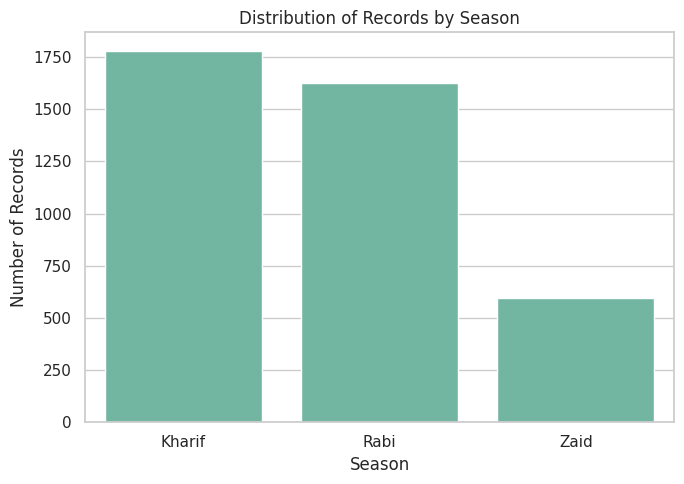

In [26]:
# Univariate: Season distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

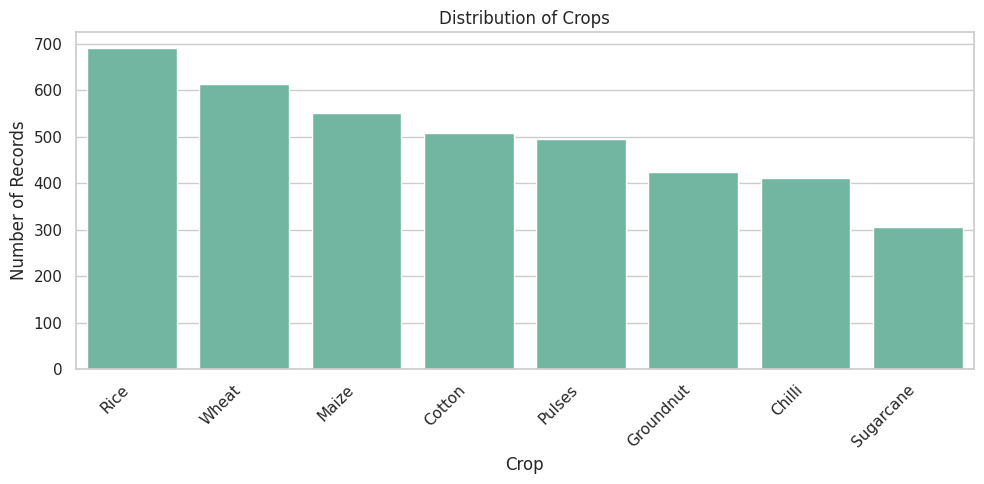

In [27]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

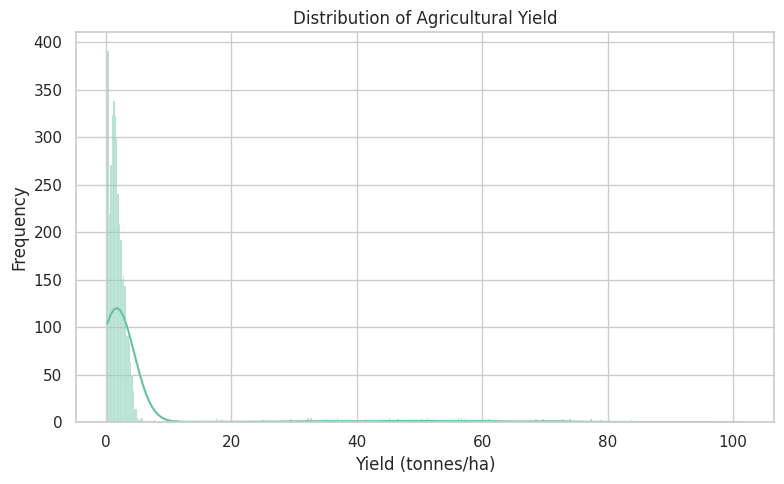

In [29]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

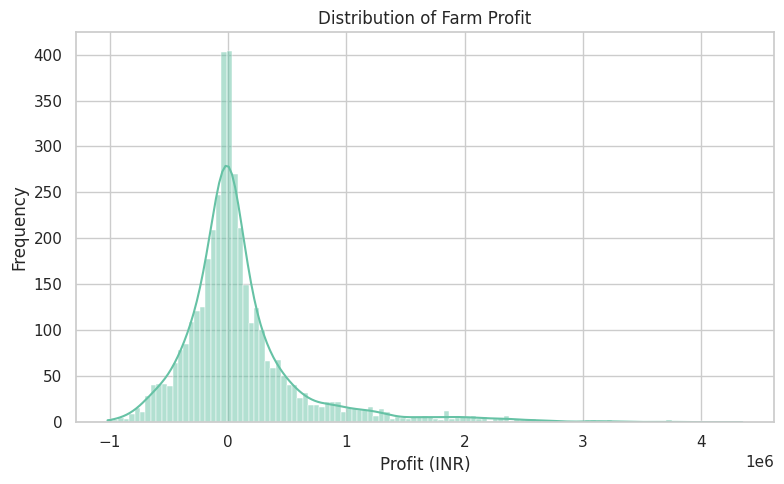

In [28]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

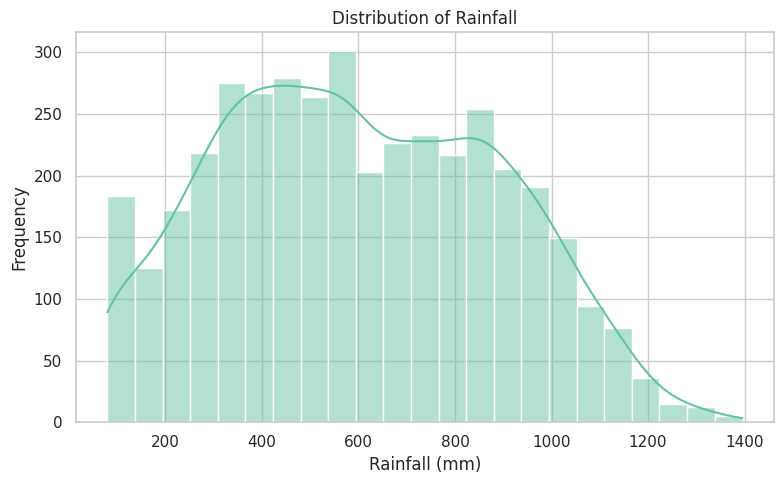

In [30]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

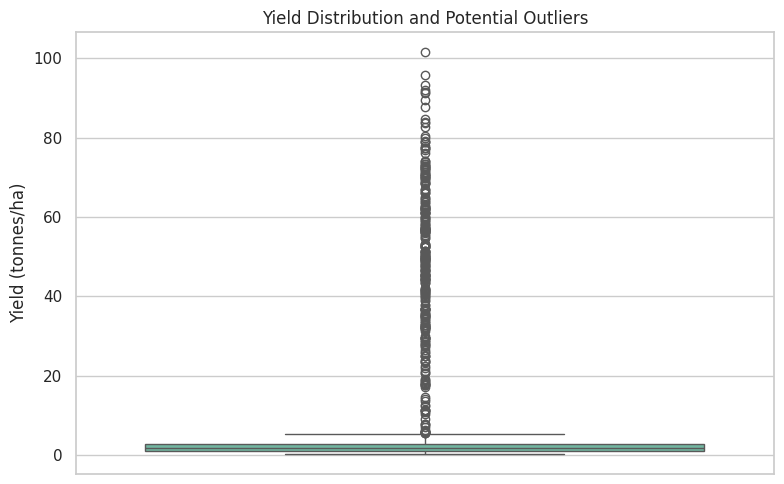

In [31]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

##9. Outlier Analysis

Investigate potential outliers using statistical and visual methods.



*   A data-entry problem,
*   A legitimate observation,

*   Or something requiring further investigation.



Or something requiring further investigation.

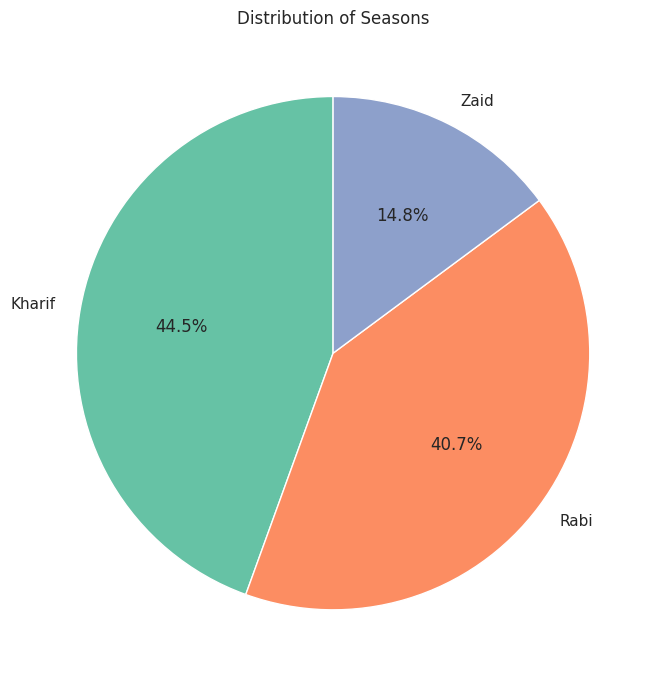

In [32]:
# Univariate: Season distribution (Pie Chart)
plt.figure(figsize=(7, 7))

df["Season"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Seasons")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [36]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("Outlier_Count",ascending=False)
outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


##10.Bivariate analysis
Bivariate analysis examines relationships or differences between two variables.

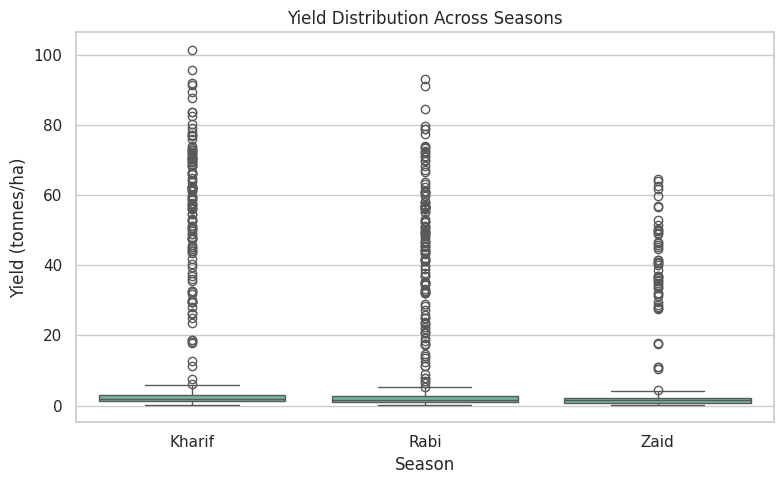

In [37]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

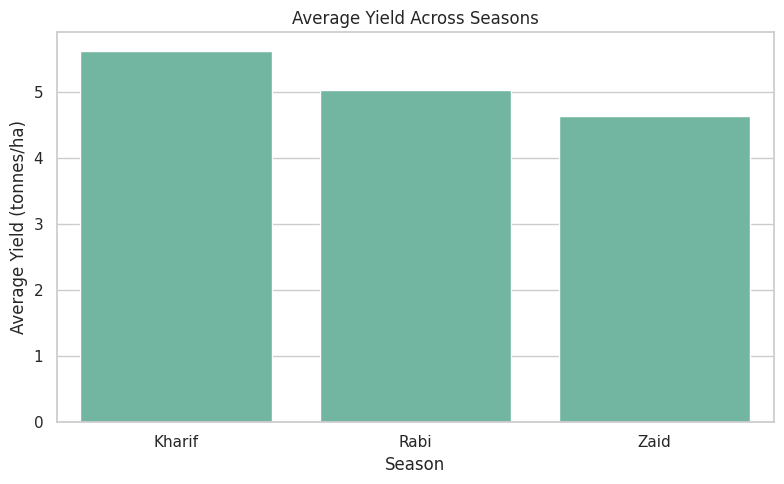

In [38]:


avg_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_yield, x="Season", y="Yield_Tonnes_Ha")
plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

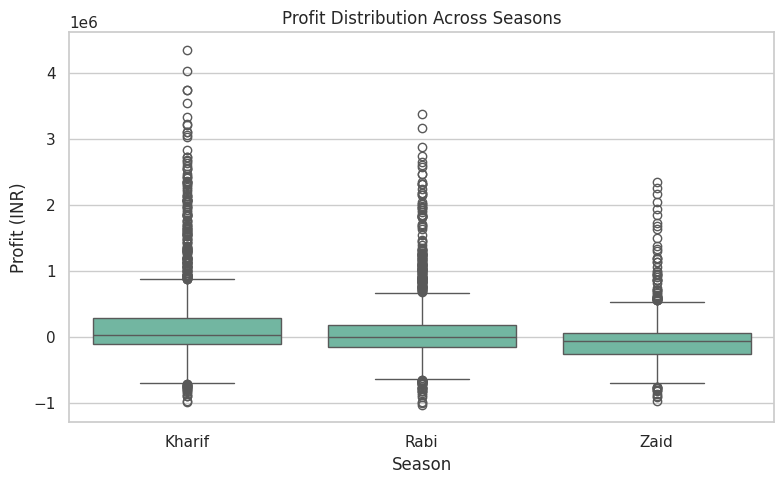

In [39]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

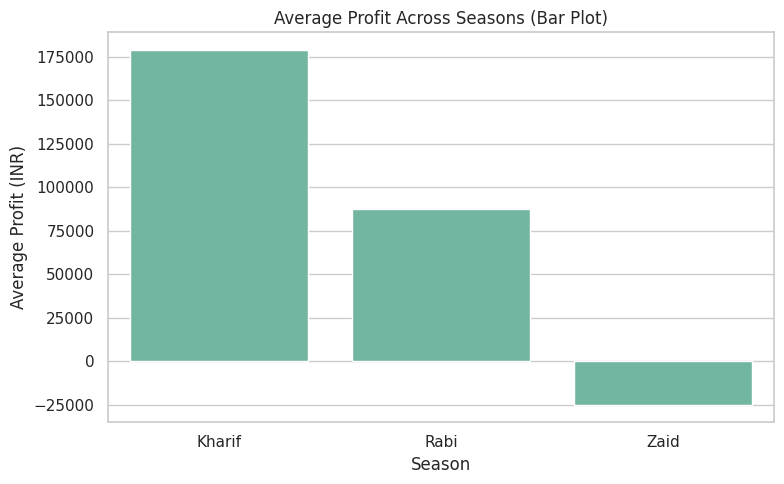

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

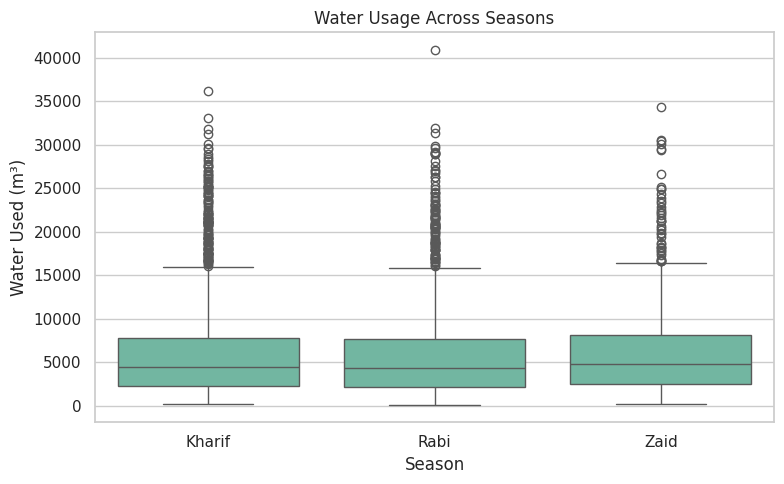

In [41]:
# Bivariate: Season vs Water Usage

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

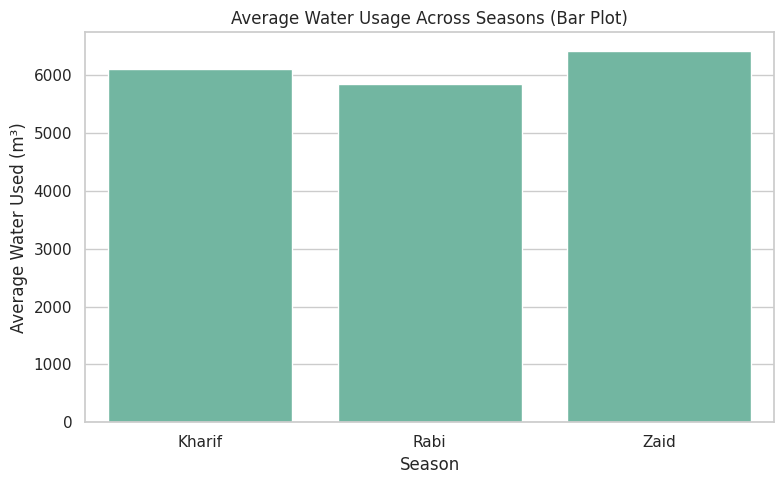

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

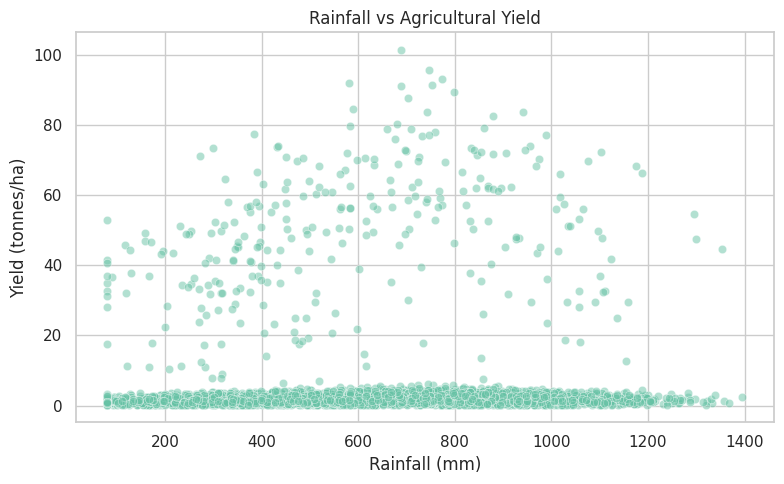

In [43]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

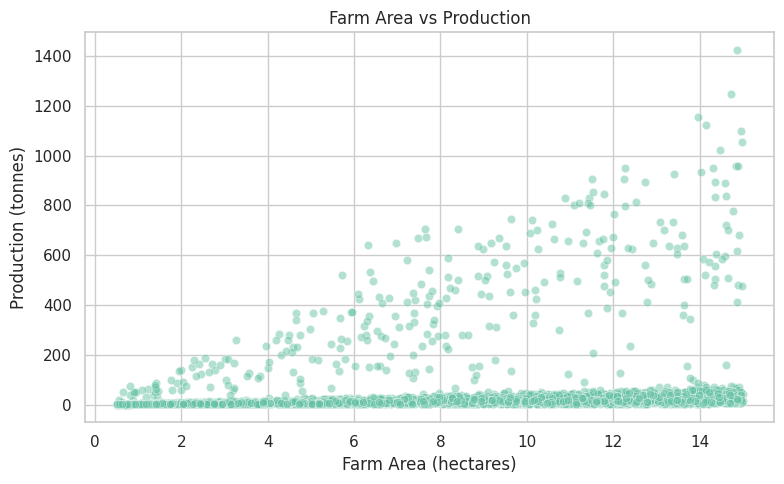

In [44]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

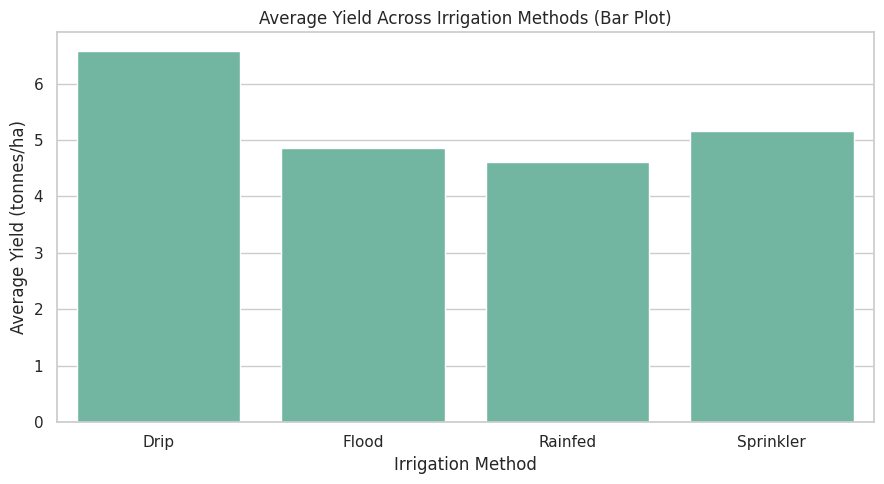

In [45]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

##11. Multivariate Analysis
Multivariate analysis examines more than two variables together.

Use multivariate plots to investigate how season interacts with other dimensions such as crop, region, environmental conditions, resource usage or economic performance.

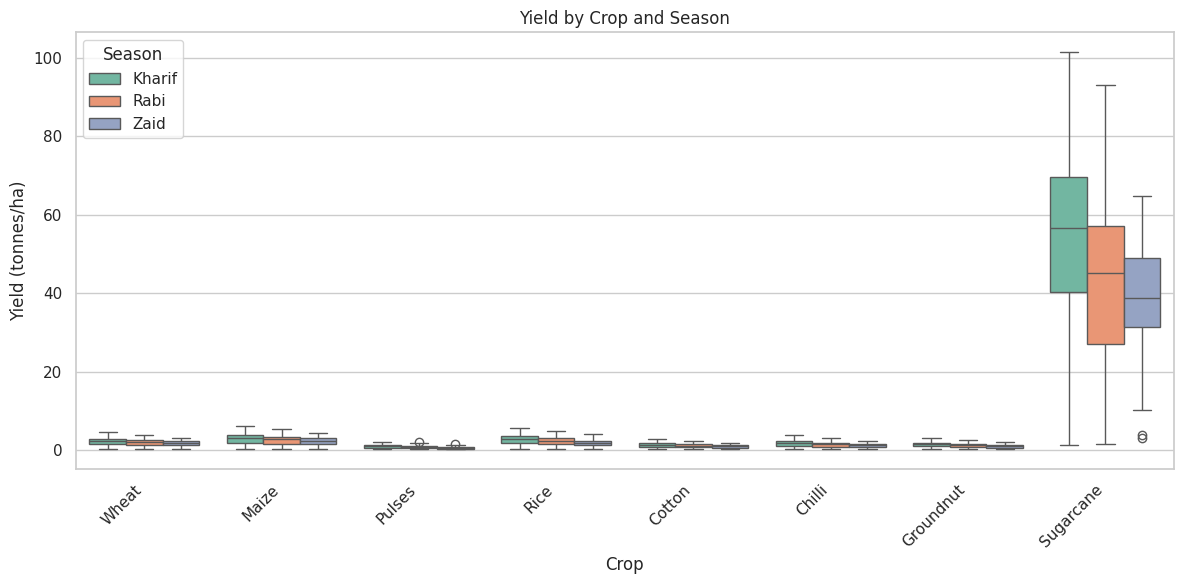

In [46]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

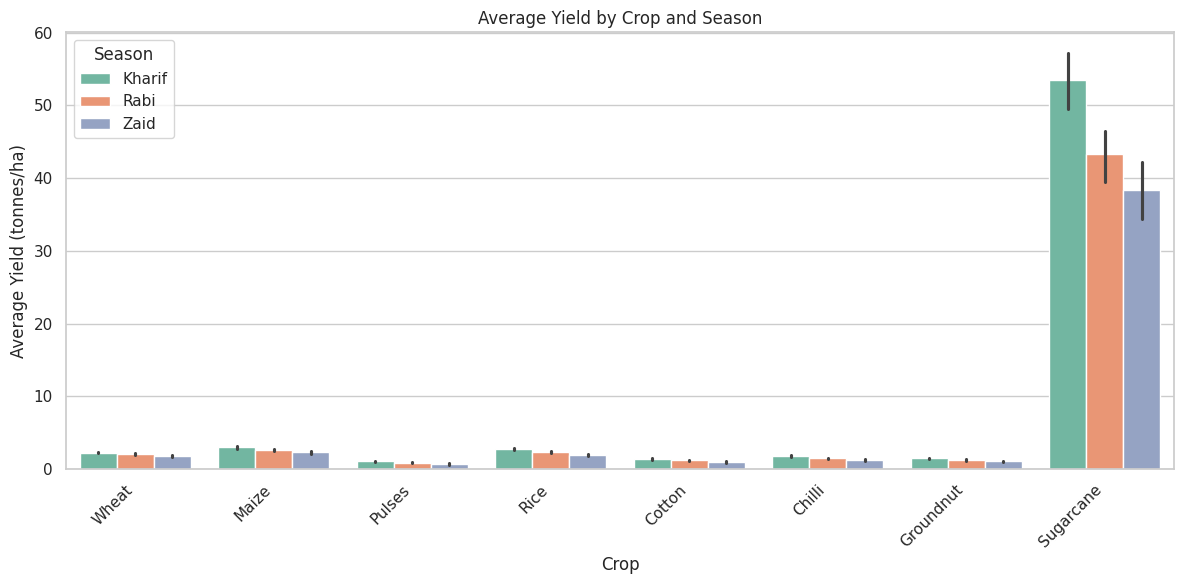

In [50]:
# Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    estimator="mean"
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()



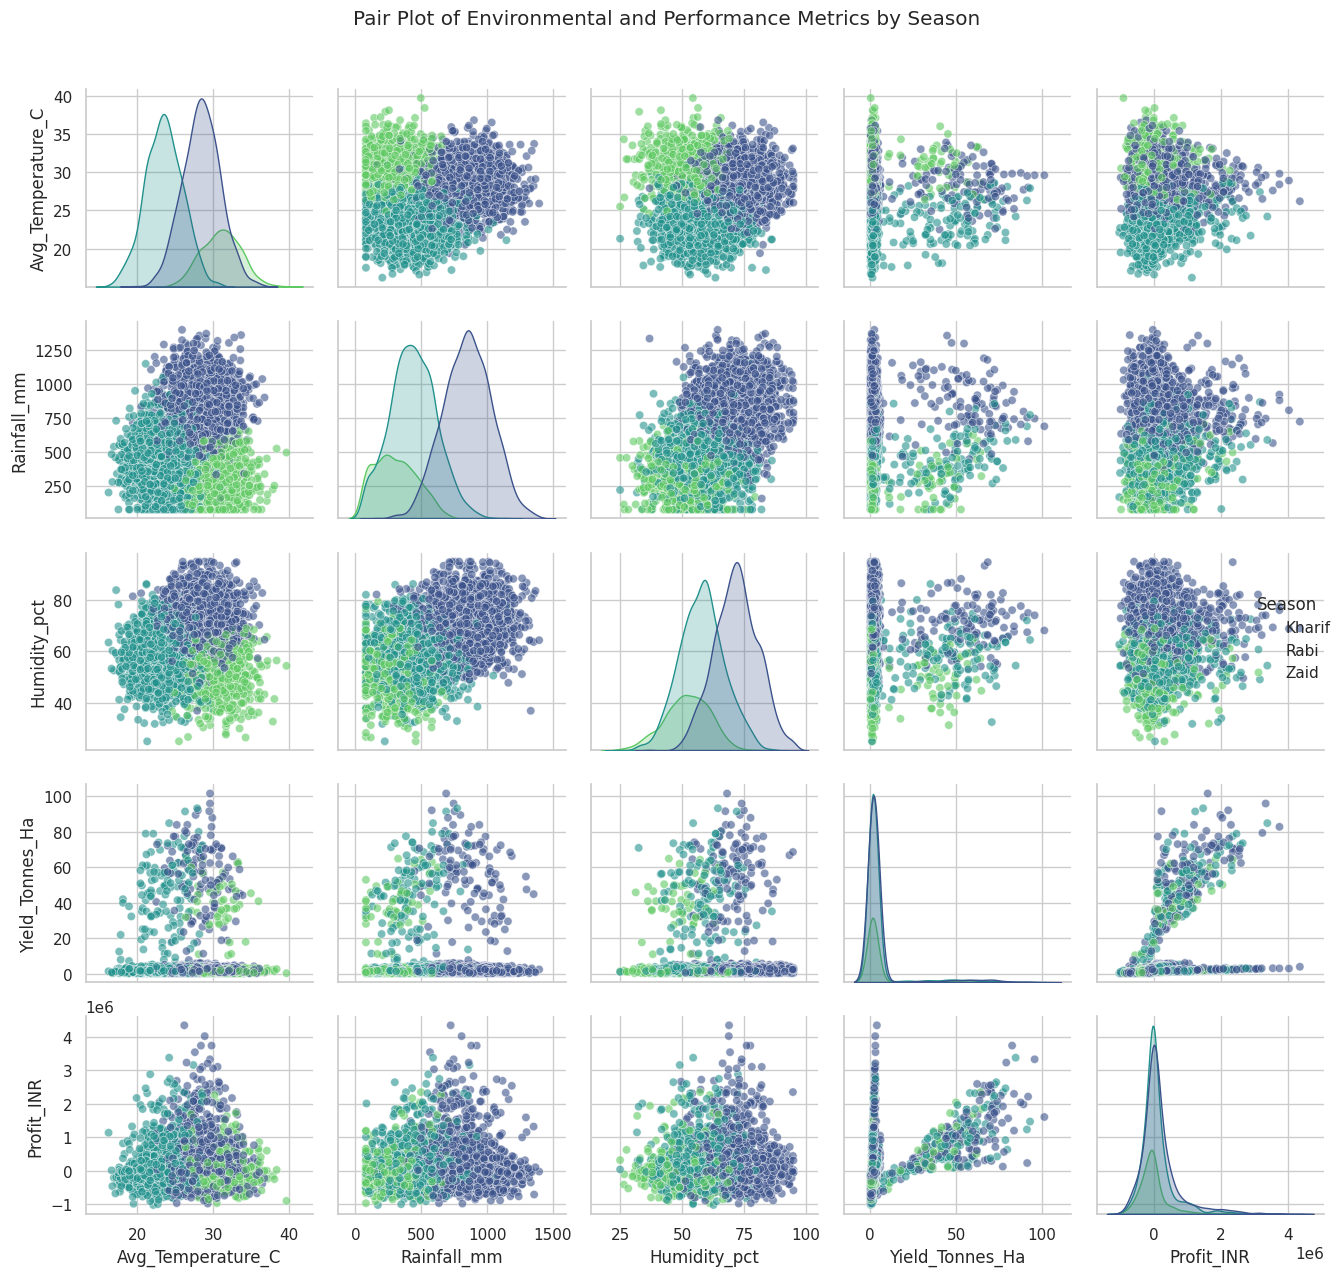

In [51]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']

sns.pairplot(
    df[selected_columns],
    hue='Season',
    palette='viridis',
    plot_kws={'alpha': 0.6}
)

plt.suptitle(
    'Pair Plot of Environmental and Performance Metrics by Season',
    y=1.02
)  # Adjust subtitle position

plt.tight_layout()
plt.show()

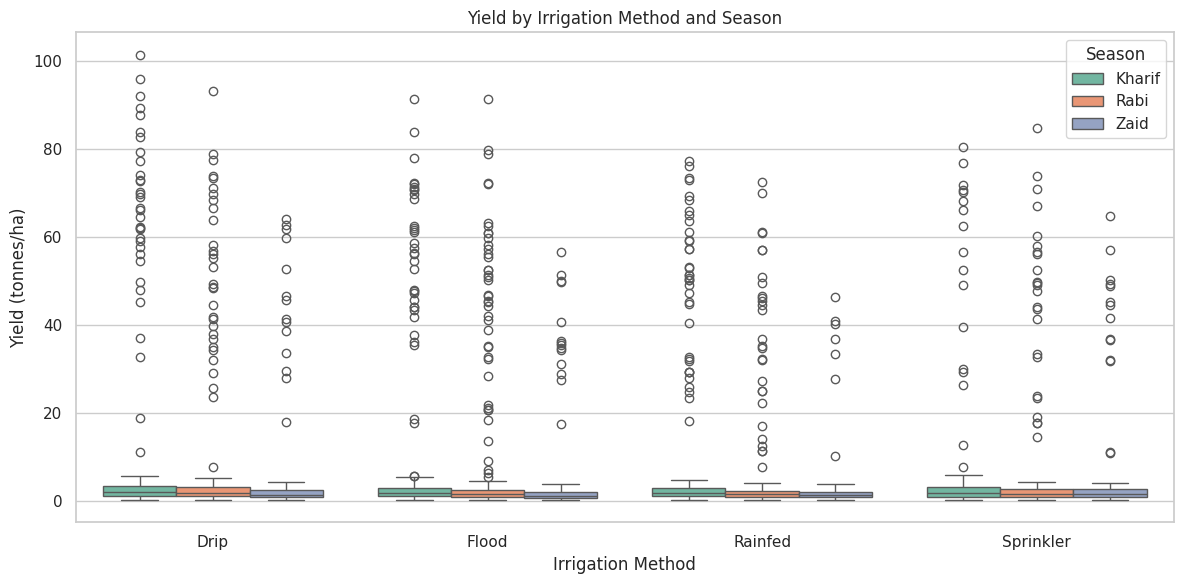

In [52]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

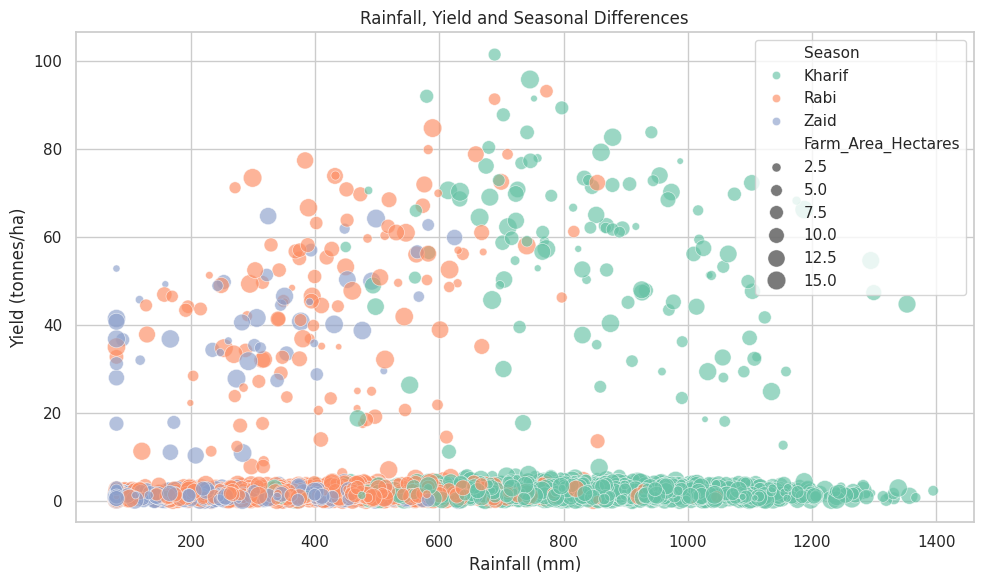

In [53]:
# Multivariate: Rainfall, yield and season

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)

plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

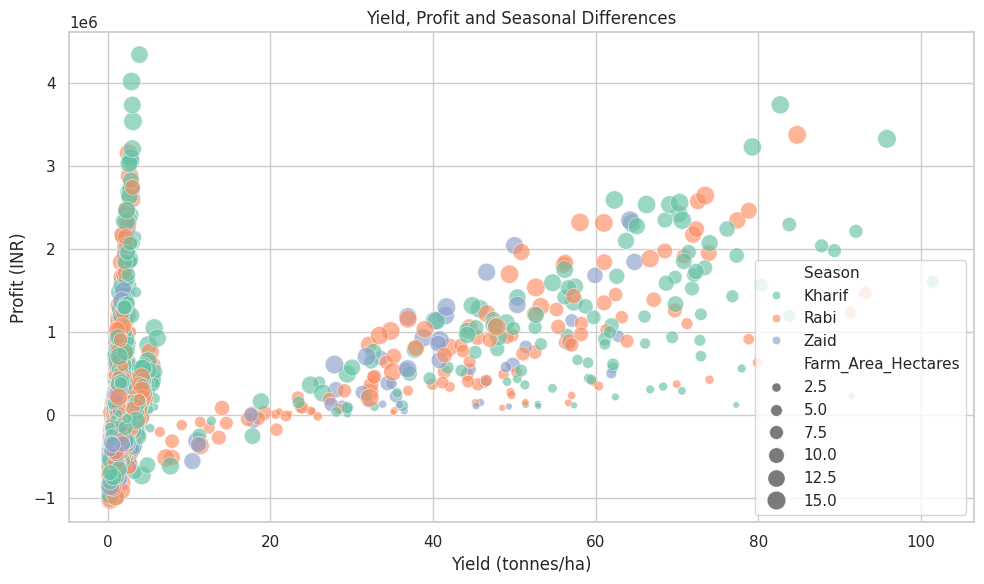

In [54]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)

plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

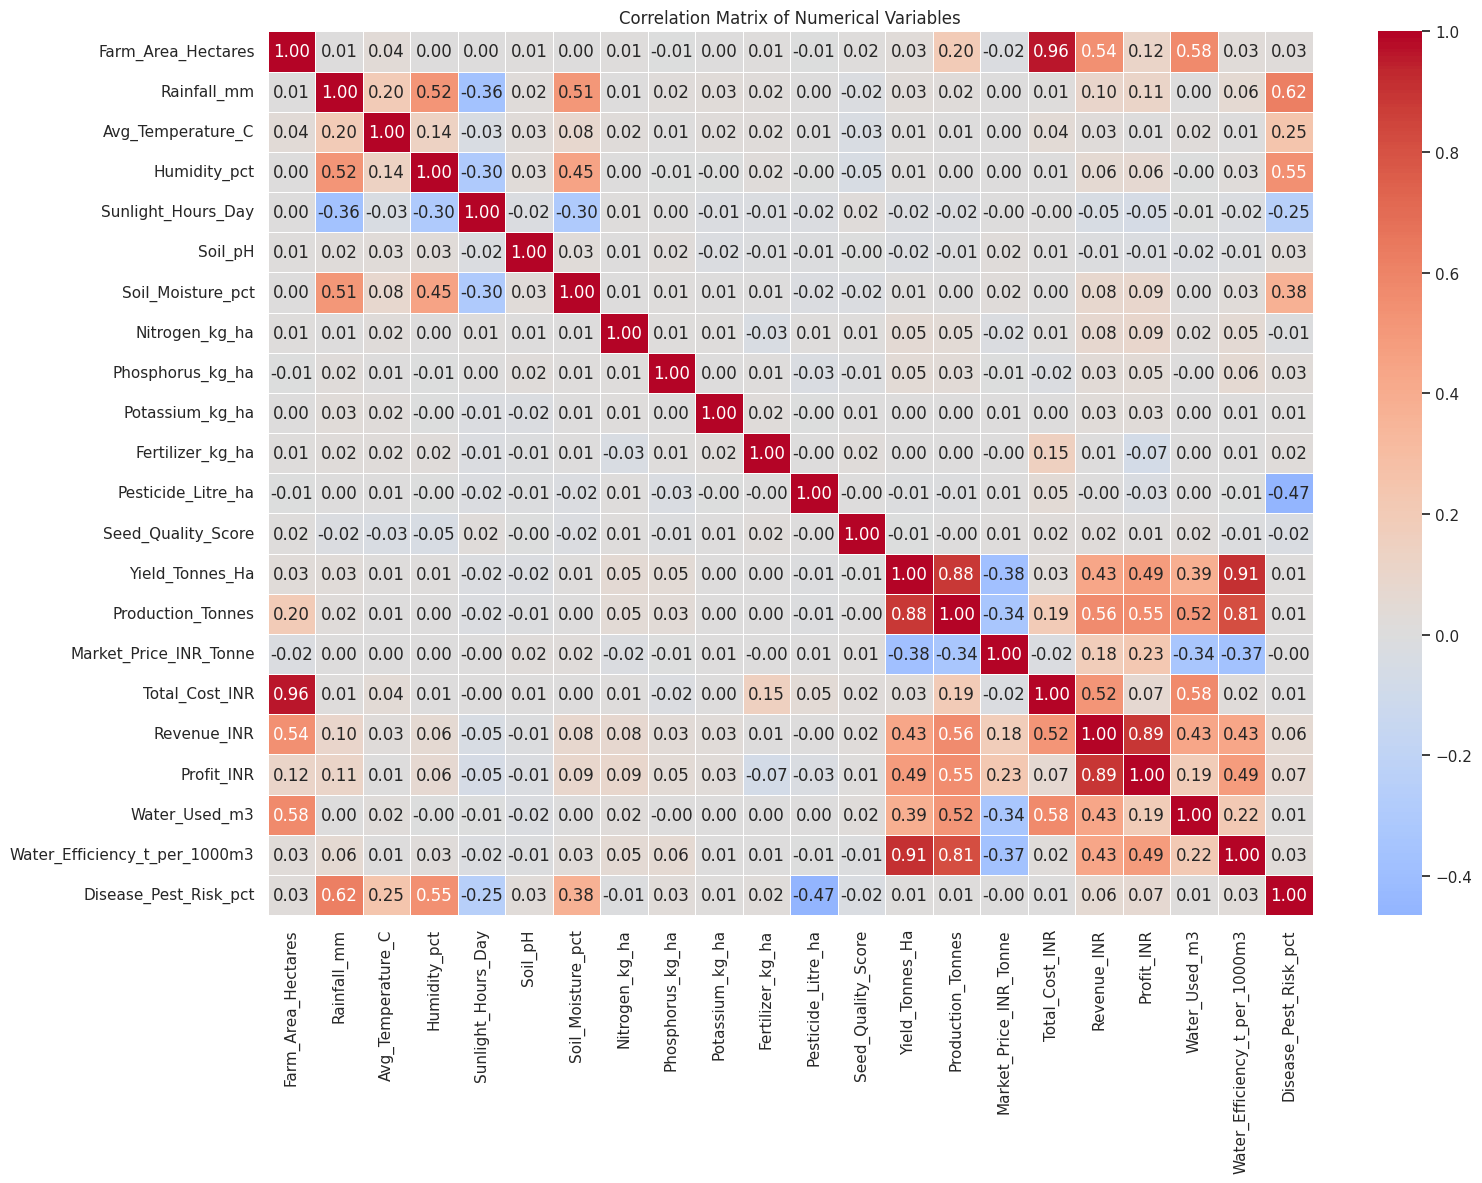

In [55]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))

corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

##12.Seasonal comparison
move from indiviual plot to comparison structure

In [57]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


In [58]:
# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(
          ["Season", "Average_Yield"],
          ascending=[True, False]
      )
)

print(crop_season_summary)

                  Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.70       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.29       731612.86                     27.92
       Maize               2.60       -89133.40                      5.46
       Rice                2.32       -98427.87                      1.84
       Wheat               2.06      -

##13.Additional analysis

                Records  Average_Yield  Average_Profit  Average_Water_Used
State                                                                     
Punjab              484           6.12       136025.64             6565.92
Maharashtra         512           5.02       135428.86             5968.08
Karnataka           489           5.69       119422.34             6414.33
Tamil Nadu          485           4.88       117744.75             5775.22
Gujarat             488           5.66       117568.24             6142.50
Telangana           516           5.04       108829.62             5801.83
Madhya Pradesh      497           4.99        86840.76             5663.92
Andhra Pradesh      529           4.63        73453.53             6058.38


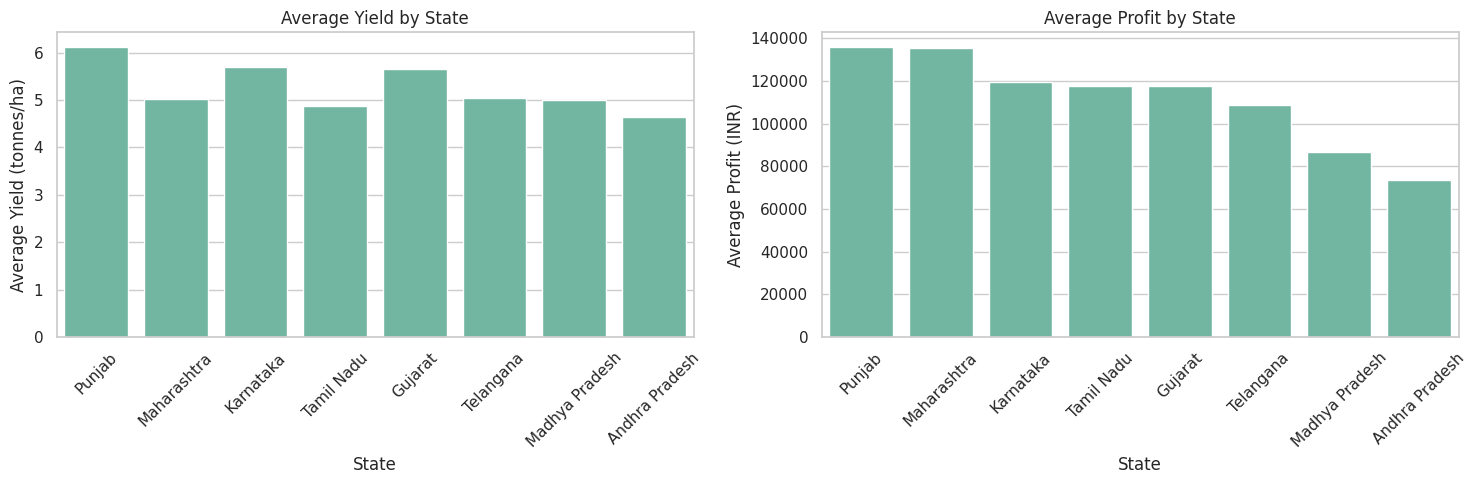

In [59]:
# Student Analysis 1
# Question: Do farms in different states differ meaningfully in average yield and profit?
#
# Relevance: The dataset spans 8 states. State-level differences in soil, climate and
# farming practice are not captured by season alone, so this analysis checks whether
# "where" a farm is located is associated with performance, independent of season.

state_summary = df.groupby("State").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2).sort_values("Average_Profit", ascending=False)

print(state_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=state_summary.reset_index(), x="State", y="Average_Yield", ax=axes[0])
axes[0].set_title("Average Yield by State")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Average Yield (tonnes/ha)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=state_summary.reset_index(), x="State", y="Average_Profit", ax=axes[1])
axes[1].set_title("Average Profit by State")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Average Profit (INR)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Punjab and Maharashtra show the highest average profit, while Andhra Pradesh and Madhya Pradesh trail behind, even though the gap in average yield across states is comparatively narrow. This suggests profit differences across states are driven by more than yield alone (e.g. cost structure, market price, or crop mix in that state), which is explored further in the resource and crop analyses below.

Average Yield (tonnes/ha) by Crop and Season
Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.47   1.20
Cotton       1.37   1.20   0.96
Groundnut    1.48   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.67
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.29  38.42
Wheat        2.25   2.06   1.75

Average Profit (INR) by Crop and Season
Season        Kharif      Rabi      Zaid
Crop                                    
Chilli      954380.0  638572.0  448659.0
Cotton      217000.0  107344.0  -53925.0
Groundnut   108265.0   10417.0  -68872.0
Maize       -39333.0  -89133.0 -194049.0
Pulses       43339.0  -14309.0 -139228.0
Rice        -64903.0  -98428.0 -227239.0
Sugarcane  1000791.0  731613.0  583636.0
Wheat      -105872.0 -119955.0 -193209.0


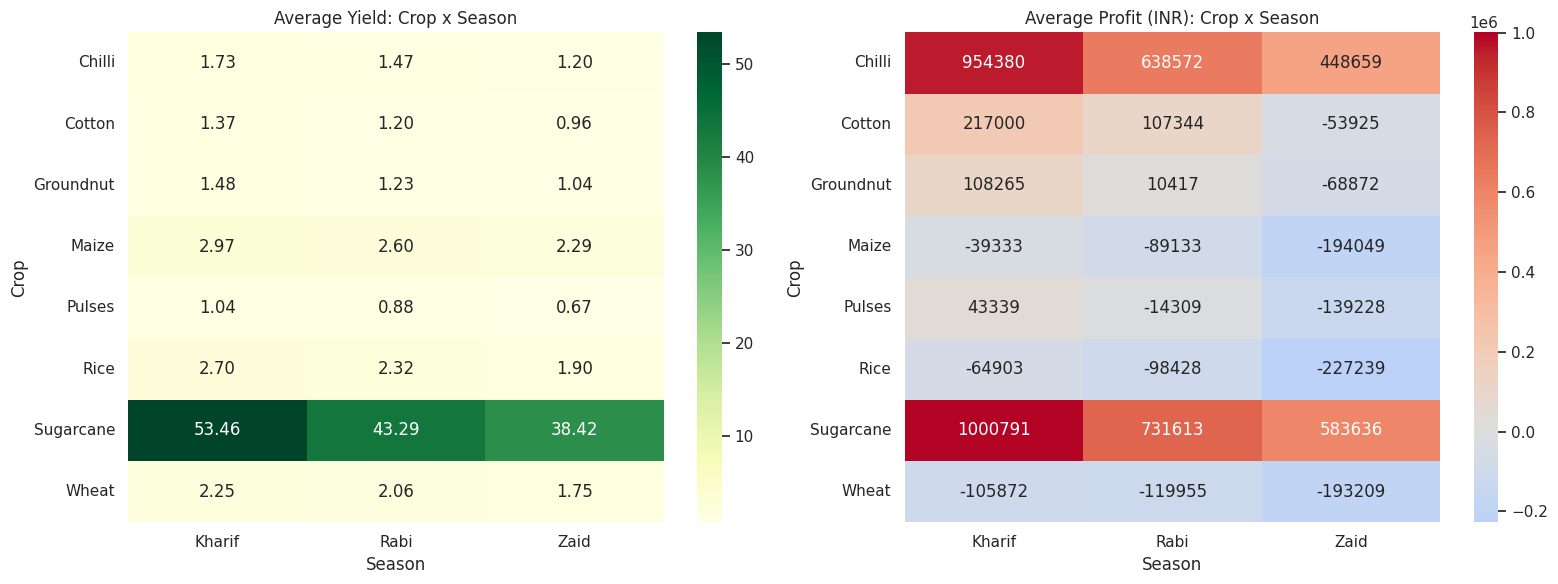

In [60]:
# Student Analysis 2
# Question: Which season is most favorable for each crop, in terms of both yield and profit?
#
# Relevance: Section 12 compared crops within a season; this analysis instead compares
# seasons within each crop, to see whether the "best" season is consistent across crops
# or crop-specific, and whether the highest-yielding season is also the most profitable one.

yield_pivot = df.pivot_table(index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean").round(2)
profit_pivot = df.pivot_table(index="Crop", columns="Season", values="Profit_INR", aggfunc="mean").round(0)

print("Average Yield (tonnes/ha) by Crop and Season")
print(yield_pivot)
print("\nAverage Profit (INR) by Crop and Season")
print(profit_pivot)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(yield_pivot, annot=True, fmt=".2f", cmap="YlGn", ax=axes[0])
axes[0].set_title("Average Yield: Crop x Season")

sns.heatmap(profit_pivot, annot=True, fmt=".0f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Average Profit (INR): Crop x Season")

plt.tight_layout()
plt.show()

**Interpretation:** Kharif is the highest-yielding season for every single crop in this dataset, consistent with it being the primary monsoon-fed growing season. However, the profit heatmap tells a different story: Chilli and Sugarcane are profitable in all three seasons, while Wheat, Rice, Maize, Pulses and (in Rabi/Zaid) Cotton and Groundnut show **negative** average profit despite reasonable yields. This shows that the highest-yielding season is not automatically the most profitable one — cost and market price matter as much as physical output.

                   Records  Average_Yield  Average_Water_Used_m3  \
Irrigation_Method                                                  
Rainfed               1041           4.60                3549.55   
Drip                   915           6.58                5918.75   
Sprinkler              734           5.16                6208.26   
Flood                 1310           4.86                8026.47   

                   Average_Water_Efficiency  Average_Profit  
Irrigation_Method                                            
Rainfed                                7.56        79050.37  
Drip                                   6.27       219626.00  
Sprinkler                              4.67        91121.08  
Flood                                  3.44        73354.02  


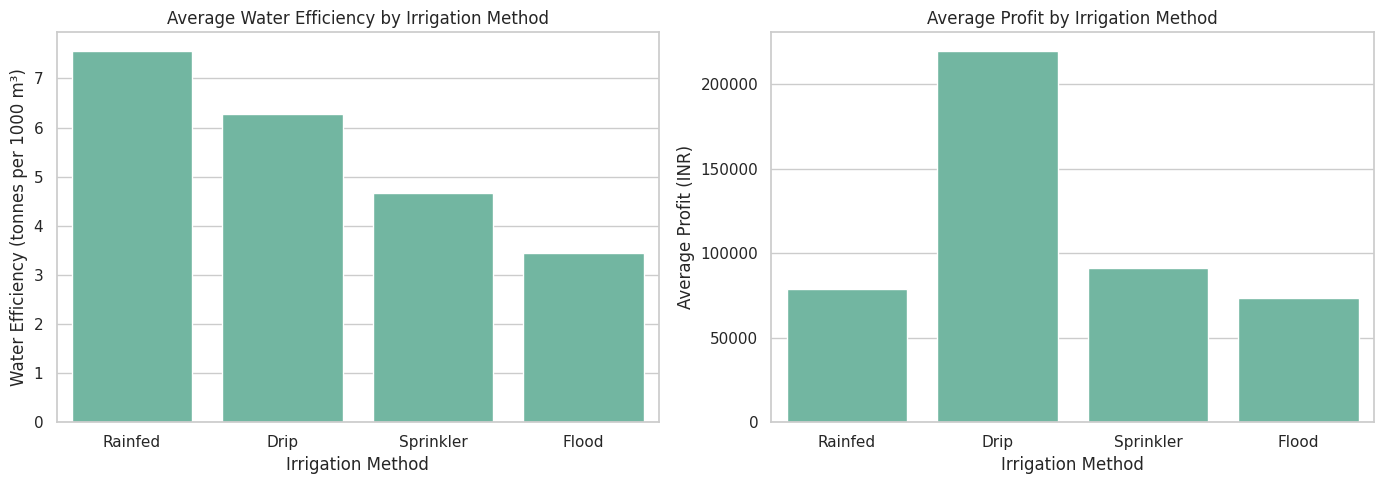

In [61]:
# Student Analysis 3
# Question: Which irrigation method delivers the best water efficiency and profit outcome?
#
# Relevance: Water is a limited agricultural resource. This analysis checks whether the
# choice of irrigation method is associated with more efficient water use and better
# profit, which is directly useful for resource-planning recommendations.

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2).sort_values("Average_Water_Efficiency", ascending=False)

print(irrigation_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=irrigation_summary.reset_index(), x="Irrigation_Method", y="Average_Water_Efficiency", ax=axes[0])
axes[0].set_title("Average Water Efficiency by Irrigation Method")
axes[0].set_xlabel("Irrigation Method")
axes[0].set_ylabel("Water Efficiency (tonnes per 1000 m³)")

sns.barplot(data=irrigation_summary.reset_index(), x="Irrigation_Method", y="Average_Profit", ax=axes[1])
axes[1].set_title("Average Profit by Irrigation Method")
axes[1].set_xlabel("Irrigation Method")
axes[1].set_ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

**Interpretation:** Rainfed farming has the highest water efficiency (tonnes produced per 1000 m³) simply because it uses the least water overall, but it also has the lowest yield and low profit. Drip irrigation uses more water than rainfed but delivers by far the highest average yield and profit, and is markedly more water-efficient than Sprinkler or Flood irrigation. Flood irrigation is the least water-efficient method and also produces the lowest average profit. This points to Drip irrigation as the strongest balance of water efficiency and profitability among the methods that involve active irrigation.

## 14. Key Insights


**1. Kharif consistently produces the highest yield across every crop.**
- *Evidence:* The Crop × Season yield heatmap (Student Analysis 2) shows Kharif as the top-yielding season for all 8 crops, without exception.
- *Interpretation:* Kharif's monsoon timing appears strongly associated with better growing conditions for this dataset's crop mix.
- *Limitation:* This is an association across seasons in the dataset, not proof that Kharif *causes* higher yield for a given farm — other seasonal factors (rainfall, temperature) move together with the season label.

**2. Higher yield does not guarantee higher profit.**
- *Evidence:* Wheat, Rice, Maize and Pulses each have solidly positive average yields but **negative** average profit margins (Wheat ≈ −92%, Rice ≈ −99%, Maize ≈ −82%), while Chilli and Sugarcane are the only crops with clearly positive average margins.
- *Interpretation:* For several crops, production cost and market price outweigh the physical output achieved, so yield alone is a poor proxy for financial success.
- *Limitation:* Profit here is computed from the dataset's cost and price fields; real-world prices fluctuate by year and location and are not captured by a single average.

**3. Drip irrigation is associated with the best yield and profit outcomes.**
- *Evidence:* Drip irrigation shows the highest average yield (6.58 t/ha) and average profit (₹2,19,626) of the four irrigation methods, and better water efficiency than Sprinkler or Flood.
- *Interpretation:* Farms using drip irrigation tend to perform better on both productivity and water-use dimensions.
- *Limitation:* Irrigation method may correlate with other unmeasured factors (farm investment level, crop choice, farmer experience) that also drive profit, so this is not necessarily a pure irrigation effect.

**4. Rainfed farming has the lowest yield and profit despite appearing "efficient".**
- *Evidence:* Rainfed farms top the water-efficiency ranking (7.56 t per 1000 m³) but have the lowest average yield (4.60 t/ha) and second-lowest average profit (₹79,050).
- *Interpretation:* The apparent efficiency of rainfed farming is a function of using very little water in absolute terms, not of superior output.
- *Limitation:* Rainfed farms are, by definition, dependent on natural rainfall, so this comparison does not account for rainfall variability year to year.

**5. Punjab and Maharashtra lead in average profit; Andhra Pradesh trails.**
- *Evidence:* Punjab (₹1,36,026) and Maharashtra (₹1,35,429) have the highest state-level average profit, while Andhra Pradesh (₹73,454) has the lowest — despite yield differences across states being comparatively small.
- *Interpretation:* State-level profit differences are likely driven by factors beyond yield alone, such as cost structure, crop mix or local market prices.
- *Limitation:* State is a broad grouping; it aggregates over districts, crops and seasons, which can mask more specific local patterns.

**6. Pest and disease risk is highest in the same season that gives the best yield.**
- *Evidence:* Average `Disease_Pest_Risk_pct` is highest in Kharif (54.5%) compared with Rabi (40.5%) and Zaid (38.2%).
- *Interpretation:* The monsoon conditions that support higher Kharif yields may also create a more favorable environment for pests and disease.
- *Limitation:* The dataset provides a risk percentage, not confirmed outbreak outcomes, so this reflects risk exposure rather than realized crop loss.

**7. Seed quality score and soil pH show almost no linear relationship with yield.**
- *Evidence:* Correlation between `Seed_Quality_Score` and `Yield_Tonnes_Ha` is approximately −0.01, and between `Soil_pH` and yield is approximately −0.02.
- *Interpretation:* Within the range of values present in this dataset, these two variables do not explain variation in yield in a simple linear way.
- *Limitation:* A near-zero linear correlation does not rule out a non-linear or threshold effect (e.g. yield may only suffer if pH falls far outside an optimal band).

**8. Sugarcane and Chilli are financial outliers relative to the other six crops.**
- *Evidence:* Sugarcane has by far the highest absolute yield (mean ≈ 45 t/ha, versus 1–3 t/ha for most other crops) and the highest average profit, while Chilli has the highest average profit margin (≈34%).
- *Interpretation:* These two crops behave very differently from the grain/pulse crops in the dataset, both agronomically (Sugarcane's yield is measured on a different scale) and financially.
- *Limitation:* Because Sugarcane's yield is an order of magnitude larger than other crops, it can dominate combined-crop averages and should generally be analyzed separately or on a normalized basis.

## 15. Recommendations

Based only on the evidence found in the dataset:

- **Prioritize Drip irrigation where feasible.** It is associated with the highest yield, the highest profit, and better water efficiency than Sprinkler or Flood — a rare combination where resource efficiency and output align.
- **Re-examine the cost structure for Wheat, Rice, Maize and Pulses.** These crops show positive yield but negative average profit margins in this dataset, so cost control or price negotiation, not yield improvement alone, is likely to matter more for these crops.
- **Plan pest and disease management specifically for the Kharif season.** Since disease/pest risk is highest exactly when yield is also highest, investment in monitoring and preventive measures during Kharif could help protect the season's yield advantage.
- **Investigate state-level cost and pricing differences**, particularly in Andhra Pradesh and Madhya Pradesh, where average profit is lowest despite yields not being far below the top-performing states.
- **Avoid using Rainfed irrigation's high water-efficiency ratio as a standalone success metric** — it reflects low water use more than strong output, and Drip irrigation delivers better yield and profit outcomes overall.
- **Treat Sugarcane separately in any combined-crop reporting or modeling**, since its yield scale is roughly an order of magnitude larger than the other crops and can distort blended averages.



## 16. Conclusion

**What the dataset revealed about seasonal agricultural performance:** Season has a clear and consistent relationship with yield — Kharif outperforms Rabi and Zaid for every crop in the dataset — but yield alone does not determine financial outcome. Profitability depends heavily on crop choice, cost structure and, to a lesser extent, region and irrigation method.

**The most important patterns discovered:** (1) Kharif's yield advantage comes with a matching rise in pest/disease risk; (2) several high-yield crops (Wheat, Rice, Maize) are financial loss-makers on average in this dataset, while Chilli and Sugarcane are the clear profit leaders; (3) Drip irrigation stands out as the method that best balances yield, profit and water efficiency.

**The most useful analytical findings:** the Crop × Season profit heatmap and the irrigation-method comparison, since both translate directly into actionable operational choices (which season to prioritize per crop, and which irrigation method to invest in).

**Important limitations:** the analysis is based on observational, cross-sectional data — it shows association, not proven causation; state and season are broad groupings that can mask more local variation; and Sugarcane's very different yield scale means blended, all-crop statistics should be read with care.

**How this analysis could support future investigation or decision-making:** the findings can guide season-specific pest management planning, prioritization of Drip irrigation investment, and a deeper cost-and-pricing review for currently loss-making crops. A natural next step would be to bring in multi-year data to check whether these patterns (especially the Kharif yield advantage and irrigation-method effects) hold consistently over time rather than in a single dataset snapshot.